# Phase 4 - Multiple Regression

Muc tieu cua notebook:

1. Danh gia association co dieu kien giua cac predictors va `G3` bang OLS. Day khong phai
   phan tich nhan qua va khong khang dinh da kiem soat day du confounding.
2. So sanh kha nang du bao ngoai mau cua baseline, Model A (khong co `G1`, `G2`) va Model B
   (co `G1`, `G2`) tren cung 5 folds.
3. Kiem tra multicollinearity, residual, influential observations va cac sensitivity da
   dinh truoc trong `.docs/NOTEBOOK_04_REGRESSION_PLAN.md`.

Random cross-validation o day danh gia hoc sinh moi trong cung cau truc hai truong, khong
chung minh kha nang tong quat sang mot truong moi.


## 1. Setup va kiem tra du lieu

Mau chinh giu day du 395 hoc sinh, bao gom `G3=0`. Preprocessing duoc fit trong tung
training fold. Stratification dung `failures == 0` so voi `failures > 0`, khong dung `G3`.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
ALPHA = 0.05
ROOT = Path("..").resolve()
DATA_OUT = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "report" / "figures"
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.max_columns", 80)

df = pd.read_csv(DATA_OUT / "student_mat_clean.csv")
expected = {"G1", "G2", "G3", "failures", "school", "absences"}
assert expected.issubset(df.columns)
assert len(df) == 395 and df["G3"].isna().sum() == 0

print(f"Shape: {df.shape}")
print(f"G3=0: {(df['G3'] == 0).sum()}; G3>0: {(df['G3'] > 0).sum()}")
print(df.groupby("failures").size().rename("n"))
print(df.groupby("school").size().rename("n"))


Shape: (395, 33)
G3=0: 38; G3>0: 357
failures
0    312
1     50
2     17
3     16
Name: n, dtype: int64
school
GP    349
MS     46
Name: n, dtype: int64


## 2. Cross-validation va out-of-fold predictions

Aggregate metrics tren toan bo OOF predictions la ket qua chinh. Fold metrics chi dung de
xem variability va paired differences; SD cua 5 folds khong duoc dien giai la confidence
interval.


In [2]:
TARGET = "G3"
MODEL_A_FEATURES = [c for c in df.columns if c not in ["G1", "G2", "G3"]]
MODEL_B_FEATURES = [c for c in df.columns if c != "G3"]
ORDINAL_VARIABLES = [
    "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel",
    "freetime", "goout", "Dalc", "Walc", "health"
]

def make_pipeline(features, estimator=None, ordinal_as_category=False):
    X = df[features]
    categorical = X.select_dtypes(include="object").columns.tolist()
    if ordinal_as_category:
        categorical += [c for c in ORDINAL_VARIABLES if c in features]
    categorical = list(dict.fromkeys(categorical))
    numeric = [c for c in features if c not in categorical]
    preprocessor = ColumnTransformer([
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
        ("numeric", StandardScaler(), numeric),
    ])
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator if estimator is not None else LinearRegression()),
    ])

strata = np.where(df["failures"].eq(0), "no_previous_failure", "previous_failure")
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
splits = list(splitter.split(df, strata))
fold_id = np.empty(len(df), dtype=int)
for fold, (_, test_idx) in enumerate(splits, start=1):
    fold_id[test_idx] = fold

fold_check = (
    pd.DataFrame({"fold": fold_id, "G3": df["G3"], "failures": df["failures"], "school": df["school"]})
    .groupby("fold")
    .agg(n=("G3", "size"), mean_G3=("G3", "mean"), failure_rate=("failures", lambda x: (x > 0).mean()),
         MS_rate=("school", lambda x: (x == "MS").mean()))
)
display(fold_check.round(3))

model_specs = {
    "Baseline": (MODEL_A_FEATURES, Pipeline([("model", DummyRegressor(strategy="mean"))])),
    "Model A": (MODEL_A_FEATURES, make_pipeline(MODEL_A_FEATURES)),
    "Model B": (MODEL_B_FEATURES, make_pipeline(MODEL_B_FEATURES)),
}

oof_frames = []
fold_rows = []
for model_name, (features, pipeline) in model_specs.items():
    predictions = np.full(len(df), np.nan)
    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        pipeline.fit(df.iloc[train_idx][features], df.iloc[train_idx][TARGET])
        pred = pipeline.predict(df.iloc[test_idx][features])
        predictions[test_idx] = pred
        y_test = df.iloc[test_idx][TARGET]
        fold_rows.append({
            "result_type": "fold", "model": model_name, "fold": fold,
            "n": len(test_idx), "rmse": mean_squared_error(y_test, pred) ** 0.5,
            "mae": mean_absolute_error(y_test, pred), "r2": r2_score(y_test, pred),
        })
    oof_frames.append(pd.DataFrame({
        "row_id": np.arange(len(df)), "fold": fold_id, "model": model_name,
        "observed_G3": df[TARGET], "predicted_G3": predictions,
        "school": df["school"], "failures": df["failures"],
        "outside_0_20": (predictions < 0) | (predictions > 20),
    }))

oof = pd.concat(oof_frames, ignore_index=True)
aggregate_rows = []
for model_name, group in oof.groupby("model", sort=False):
    aggregate_rows.append({
        "result_type": "aggregate_oof", "model": model_name, "fold": np.nan,
        "n": len(group), "rmse": mean_squared_error(group["observed_G3"], group["predicted_G3"]) ** 0.5,
        "mae": mean_absolute_error(group["observed_G3"], group["predicted_G3"]),
        "r2": r2_score(group["observed_G3"], group["predicted_G3"]),
    })

cv_results = pd.concat([pd.DataFrame(fold_rows), pd.DataFrame(aggregate_rows)], ignore_index=True)
fold_wide = pd.DataFrame(fold_rows).pivot(index="fold", columns="model", values=["rmse", "mae", "r2"])
paired_rows = []
for metric in ["rmse", "mae", "r2"]:
    for fold in fold_wide.index:
        paired_rows.append({
            "result_type": "paired_B_minus_A", "model": "Model B - Model A", "fold": fold,
            "metric": metric, "difference": fold_wide.loc[fold, (metric, "Model B")] - fold_wide.loc[fold, (metric, "Model A")],
        })
paired_results = pd.DataFrame(paired_rows)

cv_results.to_csv(DATA_OUT / "regression_cv_results.csv", index=False)
paired_results.to_csv(DATA_OUT / "regression_paired_fold_differences.csv", index=False)
oof.to_csv(DATA_OUT / "regression_oof_predictions.csv", index=False)
display(cv_results.query("result_type == 'aggregate_oof'").round(3))
display(paired_results.groupby("metric")["difference"].agg(["mean", "std"]).round(3))


,n,mean_G3,failure_rate,MS_rate
fold,,,,
1,79,10.949,0.203,0.101
2,79,10.506,0.203,0.127
3,79,10.684,0.215,0.152
4,79,9.835,0.215,0.101
5,79,10.101,0.215,0.101


,result_type,model,fold,n,rmse,mae,r2
15,aggregate_oof,Baseline,NaN,395,4.585,3.435,-0.004
16,aggregate_oof,Model A,NaN,395,4.373,3.405,0.087
17,aggregate_oof,Model B,NaN,395,2.017,1.353,0.806


,mean,std
metric,,
mae,-2.051,0.222
r2,0.731,0.079
rmse,-2.421,0.368


## 3. OOF figures va subgroup diagnostics

Metric theo `school`, prediction ngoai [0,20] va clipped predictions chi la sensitivity
diagnostics. Clipping khong thay the estimator chinh.


,analysis,model,subgroup,n,rmse,mae,r2,outside_rate
0,prediction_bounds,Baseline,all,395,4.585,3.435,-0.004,0.000
1,metric_by_school,Baseline,GP,349,4.630,3.487,-0.005,0.000
2,metric_by_school,Baseline,MS,46,4.235,3.039,-0.021,0.000
3,prediction_bounds,Model A,all,395,4.368,3.402,0.089,0.005
4,metric_by_school,Model A,GP,349,4.372,3.410,0.104,0.006
5,metric_by_school,Model A,MS,46,4.380,3.364,-0.092,0.000
6,prediction_bounds,Model B,all,395,2.000,1.316,0.809,0.038
7,metric_by_school,Model B,GP,349,2.028,1.365,0.807,0.043
8,metric_by_school,Model B,MS,46,1.930,1.266,0.788,0.000


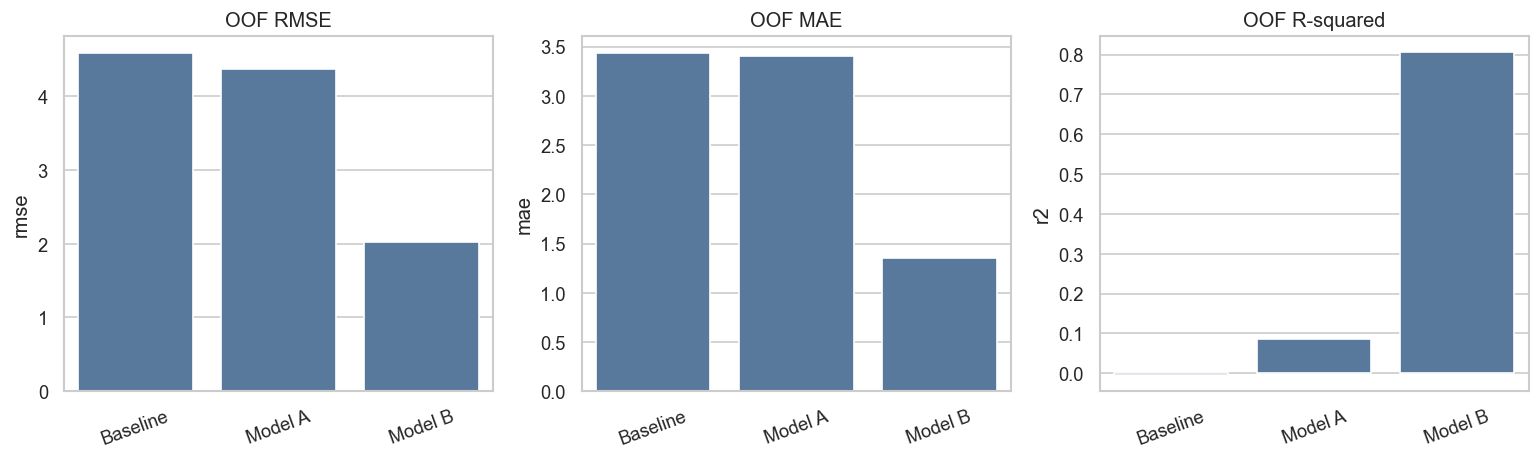

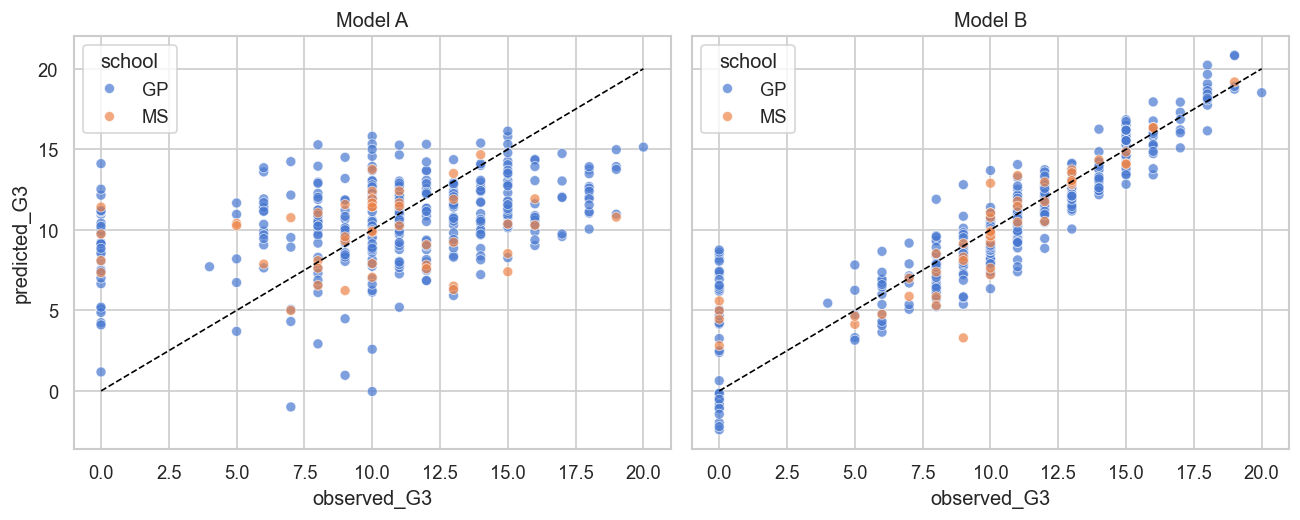

In [3]:
aggregate = cv_results.query("result_type == 'aggregate_oof'").copy()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, title in zip(axes, ["rmse", "mae", "r2"], ["OOF RMSE", "OOF MAE", "OOF R-squared"]):
    sns.barplot(data=aggregate, x="model", y=metric, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reg_cv_model_comparison.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, model_name in zip(axes, ["Model A", "Model B"]):
    group = oof[oof["model"].eq(model_name)]
    sns.scatterplot(data=group, x="observed_G3", y="predicted_G3", hue="school", alpha=0.7, ax=ax)
    ax.plot([0, 20], [0, 20], "--", color="black", linewidth=1)
    ax.set_title(model_name)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reg_observed_vs_predicted.png")
plt.show()

sensitivity_rows = []
for model_name, group in oof.groupby("model", sort=False):
    clipped = group["predicted_G3"].clip(0, 20)
    sensitivity_rows.append({
        "analysis": "prediction_bounds", "model": model_name, "subgroup": "all",
        "n": len(group), "rmse": mean_squared_error(group["observed_G3"], clipped) ** 0.5,
        "mae": mean_absolute_error(group["observed_G3"], clipped),
        "r2": r2_score(group["observed_G3"], clipped),
        "outside_rate": group["outside_0_20"].mean(),
    })
    for school, school_group in group.groupby("school"):
        sensitivity_rows.append({
            "analysis": "metric_by_school", "model": model_name, "subgroup": school,
            "n": len(school_group),
            "rmse": mean_squared_error(school_group["observed_G3"], school_group["predicted_G3"]) ** 0.5,
            "mae": mean_absolute_error(school_group["observed_G3"], school_group["predicted_G3"]),
            "r2": r2_score(school_group["observed_G3"], school_group["predicted_G3"]),
            "outside_rate": school_group["outside_0_20"].mean(),
        })
display(pd.DataFrame(sensitivity_rows).round(3))


## 4. OLS coefficients, HC3 intervals va joint tests

Coefficient p-values la exploratory. Ket luan theo term dung joint Wald tests voi Holm
correction trong tung model. Model B chu yeu la predictive vi `G1`, `G2` rat gan `G3`.


In [4]:
CATEGORICAL = df.select_dtypes(include="object").columns.tolist()

def formula_for(features, ordinal_as_category=False):
    categorical = set(CATEGORICAL)
    if ordinal_as_category:
        categorical.update(ORDINAL_VARIABLES)
    terms = [f"C({c})" if c in categorical else c for c in features]
    return "G3 ~ " + " + ".join(terms)

ols_models = {}
robust_models = {}
coefficient_frames = []
joint_frames = []
diagnostic_rows = []

for model_name, features in [("Model A", MODEL_A_FEATURES), ("Model B", MODEL_B_FEATURES)]:
    fitted = smf.ols(formula_for(features), data=df).fit()
    robust = fitted.get_robustcov_results(cov_type="HC3")
    ols_models[model_name] = fitted
    robust_models[model_name] = robust

    ci = robust.conf_int(alpha=ALPHA)
    coef = pd.DataFrame({
        "model": model_name, "term": fitted.model.exog_names,
        "coefficient": robust.params, "hc3_se": robust.bse,
        "ci_low": ci[:, 0], "ci_high": ci[:, 1], "p_raw": robust.pvalues,
    })
    coefficient_frames.append(coef)

    term_table = robust.wald_test_terms(skip_single=False, scalar=True).table.rename_axis("term").reset_index()
    term_table = term_table.rename(columns={"pvalue": "p_raw"})
    term_table = term_table[term_table["term"].ne("Intercept")].copy()
    term_table["p_holm"] = multipletests(term_table["p_raw"], method="holm")[1]
    term_table["reject_holm"] = term_table["p_holm"] < ALPHA
    term_table.insert(0, "model", model_name)
    term_table.insert(1, "specification", "main_numeric_ordinal")
    joint_frames.append(term_table)

    exog = pd.DataFrame(fitted.model.exog, columns=fitted.model.exog_names)
    non_intercept = [c for c in exog.columns if c != "Intercept"]
    vif_values = []
    for idx, column in enumerate(exog.columns):
        if column == "Intercept":
            continue
        vif_values.append((column, variance_inflation_factor(exog.values, idx)))
    condition_number = np.linalg.cond(exog.values)
    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(fitted.resid, fitted.model.exog)
    influence = fitted.get_influence()
    cooks = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    studentized = influence.resid_studentized_external
    for term, vif in vif_values:
        diagnostic_rows.append({
            "model": model_name, "record_type": "vif", "term": term, "value": vif,
            "condition_number": condition_number, "bp_pvalue": bp_lm_p,
            "n_cooks_over_4n": int((cooks > 4 / len(df)).sum()),
            "max_cooks_distance": cooks.max(), "max_leverage": leverage.max(),
            "max_abs_studentized_residual": np.nanmax(np.abs(studentized)),
        })
    for variable in [c for c in features if c in CATEGORICAL]:
        for level, count in df[variable].value_counts(dropna=False).items():
            diagnostic_rows.append({
                "model": model_name, "record_type": "category_count",
                "term": f"{variable}={level}", "value": count,
                "condition_number": condition_number, "bp_pvalue": bp_lm_p,
                "n_cooks_over_4n": int((cooks > 4 / len(df)).sum()),
                "max_cooks_distance": cooks.max(), "max_leverage": leverage.max(),
                "max_abs_studentized_residual": np.nanmax(np.abs(studentized)),
            })

coefficients = pd.concat(coefficient_frames, ignore_index=True)
joint_tests = pd.concat(joint_frames, ignore_index=True)
diagnostics = pd.DataFrame(diagnostic_rows)
coefficients.to_csv(DATA_OUT / "regression_coefficients.csv", index=False)
joint_tests.to_csv(DATA_OUT / "regression_joint_tests.csv", index=False)
diagnostics.to_csv(DATA_OUT / "regression_diagnostics.csv", index=False)

display(joint_tests[joint_tests["reject_holm"]].sort_values(["model", "p_holm"]).round(4))
display(diagnostics.query("record_type == 'vif'").groupby("model").agg(max_vif=("value", "max"), condition_number=("condition_number", "first"),
                                           bp_pvalue=("bp_pvalue", "first"), cooks_flagged=("n_cooks_over_4n", "first")).round(3))


,model,specification,term,statistic,p_raw,df_constraint,df_denom,p_holm,reject_holm
22,Model A,main_numeric_ordinal,failures,17.6733,0.0000,1,355.0,0.001,True
61,Model B,main_numeric_ordinal,G2,620.3530,0.0000,1,353.0,0.000,True
60,Model B,main_numeric_ordinal,G1,11.5838,0.0007,1,353.0,0.023,True


,max_vif,condition_number,bp_pvalue,cooks_flagged
model,,,,
Model A,6.065,442.544,0.165,31
Model B,6.152,569.060,0.000,29


## 5. Residual va influence diagnostics

Diagnostics khong phai cac test nhi phan de chap nhan/bac bo OLS. HC3 xu ly standard error
truoc heteroscedasticity, nhung khong sua nonlinearity, omitted variables hay selection bias.


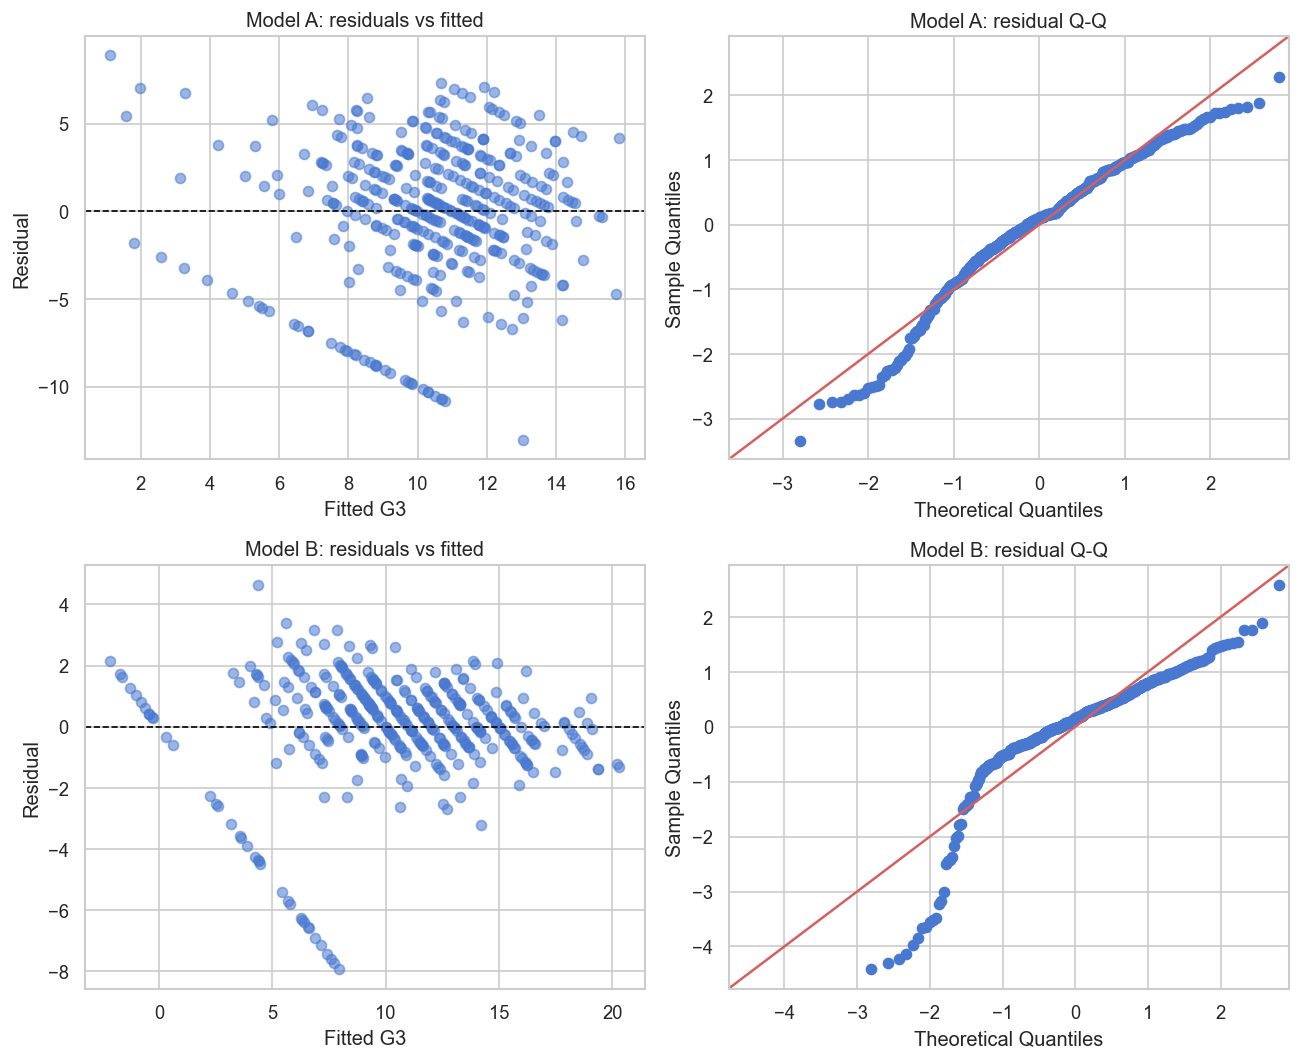

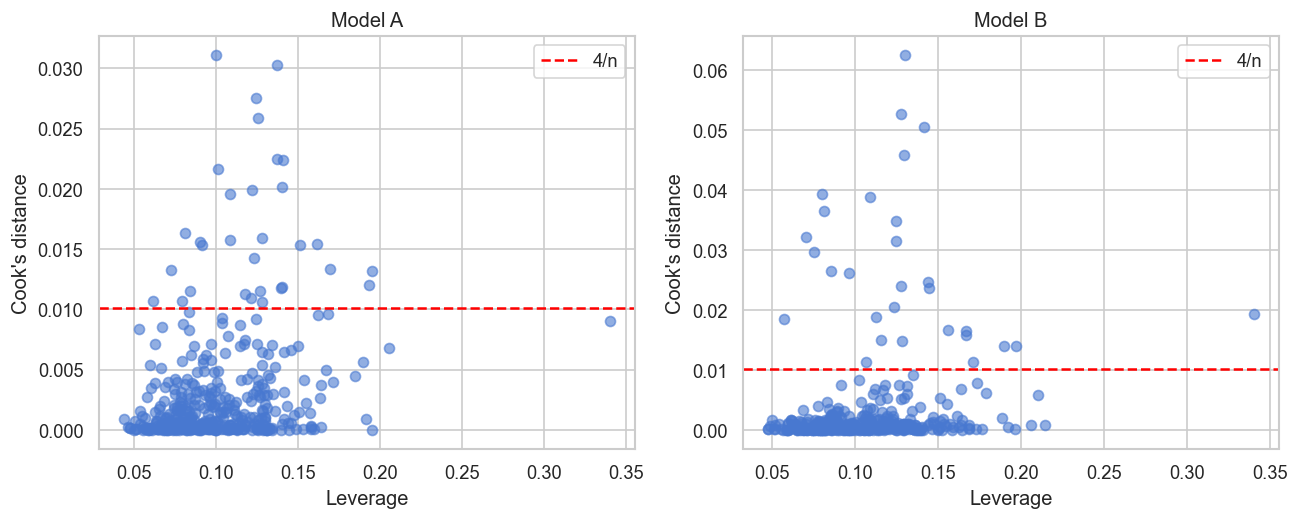

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for row, model_name in enumerate(["Model A", "Model B"]):
    fitted = ols_models[model_name]
    axes[row, 0].scatter(fitted.fittedvalues, fitted.resid, alpha=0.55)
    axes[row, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[row, 0].set_title(f"{model_name}: residuals vs fitted")
    axes[row, 0].set_xlabel("Fitted G3")
    axes[row, 0].set_ylabel("Residual")
    sm.qqplot(fitted.resid, line="45", ax=axes[row, 1], fit=True)
    axes[row, 1].set_title(f"{model_name}: residual Q-Q")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reg_residual_diagnostics.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model_name in zip(axes, ["Model A", "Model B"]):
    fitted = ols_models[model_name]
    influence = fitted.get_influence()
    cooks = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag
    ax.scatter(leverage, cooks, alpha=0.6)
    ax.axhline(4 / len(df), color="red", linestyle="--", label="4/n")
    ax.set_title(model_name)
    ax.set_xlabel("Leverage")
    ax.set_ylabel("Cook's distance")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reg_influence.png")
plt.show()


## 6. Sensitivity analyses

Sensitivity duoc bao cao rieng: ordinal-as-category, `log1p(absences)`, `G3>0`, Ridge khi
VIF > 10, metric theo school va clipping. Khong sensitivity nao thay the ket qua chinh.


In [6]:
def aggregate_oof_for_pipeline(data, features, pipeline, splits_to_use):
    pred = np.full(len(data), np.nan)
    for train_idx, test_idx in splits_to_use:
        pipeline.fit(data.iloc[train_idx][features], data.iloc[train_idx][TARGET])
        pred[test_idx] = pipeline.predict(data.iloc[test_idx][features])
    return {
        "n": len(data), "rmse": mean_squared_error(data[TARGET], pred) ** 0.5,
        "mae": mean_absolute_error(data[TARGET], pred), "r2": r2_score(data[TARGET], pred),
        "outside_rate": ((pred < 0) | (pred > 20)).mean(),
    }

for model_name, features in [("Model A", MODEL_A_FEATURES), ("Model B", MODEL_B_FEATURES)]:
    result = aggregate_oof_for_pipeline(df, features, make_pipeline(features, ordinal_as_category=True), splits)
    sensitivity_rows.append({"analysis": "ordinal_as_category", "model": model_name, "subgroup": "all", **result})
    ordinal_fit = smf.ols(formula_for(features, ordinal_as_category=True), data=df).fit().get_robustcov_results(cov_type="HC3")
    ordinal_terms = ordinal_fit.wald_test_terms(skip_single=False, scalar=True).table.rename_axis("term").reset_index()
    ordinal_terms = ordinal_terms.rename(columns={"pvalue": "p_raw"})
    ordinal_terms = ordinal_terms[ordinal_terms["term"].ne("Intercept")].copy()
    ordinal_terms["p_holm"] = multipletests(ordinal_terms["p_raw"], method="holm")[1]
    ordinal_terms["reject_holm"] = ordinal_terms["p_holm"] < ALPHA
    ordinal_terms.insert(0, "model", model_name)
    ordinal_terms.insert(1, "specification", "ordinal_as_category")
    joint_tests = pd.concat([joint_tests, ordinal_terms], ignore_index=True)

df_log = df.copy()
df_log["absences"] = np.log1p(df_log["absences"])
for model_name, features in [("Model A", MODEL_A_FEATURES), ("Model B", MODEL_B_FEATURES)]:
    result = aggregate_oof_for_pipeline(df_log, features, make_pipeline(features), splits)
    sensitivity_rows.append({"analysis": "log1p_absences", "model": model_name, "subgroup": "all", **result})

positive = df[df["G3"] > 0].reset_index(drop=True)
positive_strata = np.where(positive["failures"].eq(0), "no_previous_failure", "previous_failure")
positive_splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED).split(positive, positive_strata))
for model_name, features in [("Model A", MODEL_A_FEATURES), ("Model B", MODEL_B_FEATURES)]:
    old_df = df
    df = positive
    pipeline = make_pipeline(features)
    df = old_df
    result = aggregate_oof_for_pipeline(positive, features, pipeline, positive_splits)
    sensitivity_rows.append({"analysis": "G3_positive_only", "model": model_name, "subgroup": "all", **result})

max_vif = diagnostics.query("record_type == 'vif'").groupby("model")["value"].max()
ridge_alphas = np.logspace(-3, 3, 13)
for model_name, features in [("Model A", MODEL_A_FEATURES), ("Model B", MODEL_B_FEATURES)]:
    if max_vif[model_name] <= 10:
        continue
    ridge_pred = np.full(len(df), np.nan)
    selected_alphas = []
    for train_idx, test_idx in splits:
        ridge_pipeline = make_pipeline(features, Ridge())
        inner_strata = strata[train_idx]
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        search = GridSearchCV(ridge_pipeline, {"model__alpha": ridge_alphas}, scoring="neg_root_mean_squared_error",
                              cv=list(inner_cv.split(df.iloc[train_idx], inner_strata)))
        search.fit(df.iloc[train_idx][features], df.iloc[train_idx][TARGET])
        ridge_pred[test_idx] = search.predict(df.iloc[test_idx][features])
        selected_alphas.append(search.best_params_["model__alpha"])
    sensitivity_rows.append({
        "analysis": "nested_cv_ridge", "model": model_name, "subgroup": "all", "n": len(df),
        "rmse": mean_squared_error(df[TARGET], ridge_pred) ** 0.5,
        "mae": mean_absolute_error(df[TARGET], ridge_pred), "r2": r2_score(df[TARGET], ridge_pred),
        "outside_rate": ((ridge_pred < 0) | (ridge_pred > 20)).mean(),
        "selected_alpha_median": float(np.median(selected_alphas)),
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(DATA_OUT / "regression_sensitivity_results.csv", index=False)
joint_tests.to_csv(DATA_OUT / "regression_joint_tests.csv", index=False)
display(sensitivity.round(3))


,analysis,model,subgroup,n,rmse,mae,r2,outside_rate
0,prediction_bounds,Baseline,all,395,4.585,3.435,-0.004,0.000
1,metric_by_school,Baseline,GP,349,4.630,3.487,-0.005,0.000
2,metric_by_school,Baseline,MS,46,4.235,3.039,-0.021,0.000
3,prediction_bounds,Model A,all,395,4.368,3.402,0.089,0.005
4,metric_by_school,Model A,GP,349,4.372,3.410,0.104,0.006
5,metric_by_school,Model A,MS,46,4.380,3.364,-0.092,0.000
6,prediction_bounds,Model B,all,395,2.000,1.316,0.809,0.038
7,metric_by_school,Model B,GP,349,2.028,1.365,0.807,0.043
8,metric_by_school,Model B,MS,46,1.930,1.266,0.788,0.000
9,ordinal_as_category,Model A,all,395,4.665,3.575,-0.039,0.008


## 7. Nguyen tac dien giai ket qua

- Aggregate OOF RMSE/MAE/R-squared la bang chung chinh ve prediction.
- Joint Wald tests voi Holm correction la bang chung chinh ve statistical association theo
  term; p-value tung coefficient chi mang tinh exploratory.
- VIF cao lam giam kha nang tach dong gop rieng, khong tu dong la ly do xoa bien.
- `G1`, `G2` la target-proximal predictors. Model B co the du bao tot nhung khong thay the
  cau hoi can thiep som cua Model A.
- Moi ket qua la association/prediction trong mau quan sat hai truong, khong phai causal
  effect va khong tu dong tong quat sang truong moi.


## 8. Phân tích và diễn giải kết quả

### 8.1. Hiệu năng dự báo ngoài mẫu

Kết quả chính được đánh giá trên toàn bộ out-of-fold predictions của 395 học sinh:

| Mô hình | RMSE | MAE | OOF R-squared |
|---|---:|---:|---:|
| Baseline dự đoán trung bình | 4.585 | 3.435 | -0.004 |
| Model A, không có `G1/G2` | 4.373 | 3.405 | 0.087 |
| Model B, có `G1/G2` | 2.017 | 1.353 | 0.806 |

Model A chỉ cải thiện nhẹ so với baseline: RMSE giảm khoảng 0.21 điểm, MAE gần như không
đổi và mô hình chỉ giải thích khoảng 8.7% biến thiên ngoài mẫu. Như vậy, với đặc tả tuyến
tính hiện tại, các thông tin nền, gia đình, hành vi và xã hội chưa đủ để dự báo sớm `G3`
với độ chính xác cao. Kết quả này không có nghĩa các yếu tố đó không liên quan đến kết quả
học tập; nó chỉ cho thấy giá trị dự báo tổng hợp ngoài mẫu còn hạn chế.

Model B cải thiện rõ rệt khi thêm `G1` và `G2`: RMSE giảm trung bình 2.421 điểm và MAE giảm
2.051 điểm so với Model A trên cùng các fold. OOF R-squared tăng từ 0.087 lên 0.806. Mức cải
thiện xuất hiện ở cả năm fold, vì paired RMSE difference dao động từ -2.900 đến -2.017.
Tuy nhiên, đây là mô hình dự báo ở thời điểm muộn hơn, khi đã biết điểm quá trình. Model B
không thay thế Model A nếu mục tiêu thực tế là phát hiện sớm học sinh cần hỗ trợ.

### 8.2. Association có điều kiện và kiểm định theo term

Sau Holm correction, Model A chỉ còn `failures` có ý nghĩa thống kê (`p_holm = 0.0010`).
Trong đặc tả ordinal-numeric, tăng một mức `failures` liên quan đến giảm trung bình khoảng
1.724 điểm `G3`, khi giữ các predictors khác trong mô hình cố định; HC3 95% CI là
[-2.530, -0.917]. Khi mã hóa `failures` như categorical, joint test vẫn có ý nghĩa
(`p_holm = 0.0098`). Vì vậy, association âm của lịch sử trượt môn là kết quả tương đối ổn
định, nhưng vẫn không được diễn giải là tác động nhân quả.

Trong Model B, `G2` là predictor nổi bật nhất. Mỗi điểm `G2` cao hơn liên quan đến khoảng
0.957 điểm `G3` cao hơn, conditional on các biến còn lại; HC3 95% CI là [0.882, 1.033].
`G2` vẫn có ý nghĩa rất mạnh khi đổi cách mã hóa các biến ordinal. Hệ số `G1` là 0.189 với
HC3 95% CI [0.080, 0.298] và qua Holm trong mô hình chính, nhưng không còn qua Holm trong
ordinal-as-category sensitivity. Do đó, bằng chứng riêng cho `G1` kém ổn định hơn `G2`.
Sau khi thêm `G1/G2`, `failures` không còn có ý nghĩa riêng (`p_raw = 0.468`), phù hợp với
việc điểm quá trình đã chứa nhiều thông tin liên quan đến thành tích trước đó.

Các p-value của từng dummy coefficient chỉ mang tính exploratory. Kết luận xác nhận trong
notebook dựa trên joint Wald tests và Holm-adjusted p-values, không dựa trên việc quét các
coefficient có `p_raw < 0.05`.

### 8.3. Multicollinearity và độ ổn định của hệ số

Maximum VIF là 6.06 ở Model A và 6.15 ở Model B. Đây là mức cần thận trọng nhưng chưa vượt
ngưỡng 10 đã định trước, nên Ridge sensitivity không được kích hoạt. Condition number khá
cao (442.5 và 569.1), một phần chịu ảnh hưởng của thang đo và hệ thống dummy variables.
Vì vậy, không nên tách đóng góp riêng của các predictors tương quan cao chỉ từ dấu hoặc
p-value của từng hệ số. Kết luận theo term, confidence interval và hiệu năng ngoài mẫu đáng
tin cậy hơn việc xếp hạng các hệ số riêng lẻ.

### 8.4. Residual diagnostics và giới hạn của OLS

Breusch-Pagan test không cho thấy heteroscedasticity rõ ở Model A (`p = 0.165`), nhưng có
bằng chứng mạnh ở Model B (`p = 5.42e-05`). Vì vậy, HC3 standard errors được dùng cho suy
diễn hệ số. Model A có 31 và Model B có 29 quan sát vượt ngưỡng tham khảo Cook's distance
`4/n`; đây là cờ để kiểm tra độ nhạy, không phải lý do tự động loại quan sát.

Residual plots cho thấy một dải chéo rõ liên quan đến nhóm `G3=0`, cùng độ lệch ở hai đuôi
Q-Q plot, đặc biệt trong Model B. Điều này cho thấy OLS không mô tả hoàn hảo point mass tại
0 và phân phối bị chặn của `G3`. HC3 chỉ làm standard errors bền vững hơn trước phương sai
không đồng nhất; nó không sửa nonlinearity, point mass tại 0 hay omitted-variable bias.
Vì thế, OLS ở đây phù hợp như một mean model minh bạch, còn đánh giá dự báo phải dựa trên
OOF metrics thay vì độ khớp trong mẫu.

### 8.5. Sensitivity analyses

- Mã hóa ordinal như categorical làm Model A kém baseline (`R-squared = -0.039`) và làm
  Model B giảm còn 0.780. Việc tăng nhiều bậc tự do không cải thiện tổng quát hóa trong mẫu
  nhỏ này, dù association của `failures` và vai trò của `G2` vẫn giữ được.
- Dùng `log1p(absences)` cải thiện nhẹ Model A lên OOF R-squared 0.121 và Model B lên 0.823.
  Đây chỉ là sensitivity result; phân tích chính vẫn giữ `absences` trên thang gốc.
- Khi chỉ xét `G3>0` (`n=357`), OOF R-squared tăng lên 0.160 cho Model A và 0.926 cho Model
  B. Nhóm điểm 0 ảnh hưởng đáng kể đến độ khớp, nhưng kết quả này không thay thế phân tích
  chính vì project đã quyết định giữ `G3=0`.
- Model A có R-squared 0.104 tại `GP` nhưng -0.092 tại `MS` (`n=46`). Model B ổn định hơn,
  với R-squared lần lượt 0.807 và 0.788. Tuy nhiên, random CV chỉ đánh giá học sinh mới trong
  cùng cấu trúc hai trường và không chứng minh khả năng tổng quát sang một trường mới.
- Khoảng 0.5% OOF predictions của Model A và 3.8% của Model B nằm ngoài thang [0,20].
  Clipping cải thiện metric nhẹ nhưng làm thay đổi estimator, nên chỉ được xem là sensitivity.

### 8.6. Kết luận chung

Model A cho thấy dự báo sớm `G3` từ các biến nền và hành vi là một bài toán khó: mô hình có
thể phát hiện association ổn định của `failures`, nhưng khả năng dự báo ngoài mẫu chỉ cải
thiện nhẹ so với dự đoán trung bình. Model B có hiệu năng cao nhờ `G1/G2`, đặc biệt là `G2`,
nhưng phù hợp với dự báo ở thời điểm muộn hơn và ít hữu ích hơn cho can thiệp sớm.

Kết quả của Phase 4 nên được trình bày như bằng chứng về association có điều kiện và khả
năng prediction trong mẫu quan sát hai trường. Không có kết quả nào chứng minh quan hệ nhân
quả, loại bỏ hoàn toàn confounding hoặc bảo đảm tổng quát hóa sang trường khác.
